In [1]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
!nvidia-smi
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import  sklearn
from sklearn.model_selection import train_test_split
#import ray
import os
import math
import matplotlib.pyplot as plt
import tensorflow.keras.optimizers.schedules as schedules
import pickle

Tue Nov 28 01:05:41 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.61.05    Driver Version: 520.61.05    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  On   | 00000000:05:00.0 Off |                  N/A |
|  0%   31C    P8    13W / 198W |      1MiB /  8192MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  On   | 00000000:06:00.0 Off |                  N/A |
| 28%   

2023-11-28 01:05:42.276568: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-28 01:05:42.417609: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-11-28 01:05:43.770868: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-11-28 01:05:43.770953: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or 

In [3]:


gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

originaldir = os.getcwd()
originaldir

"""# Data processing

For the homework, you should download the dataset with the provided link. The provided dataset has already partitioned the data by clients.
"""

os.chdir('/nfs/home/dem1110/Assignment 3/Part 2/')

train_data = 'train_data.npy'
train_data_arr = np.load(train_data, allow_pickle=True)
test_data = 'test_data.npy'
test_data_arr = np.load(test_data, allow_pickle=True)

os.chdir(originaldir)
os.getcwd()

"""# Define model"""

## regular model
'''
def get_model():
    model = tf.keras.models.Sequential(
        [ tf.keras.layers.Flatten(input_shape=(28, 28)),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(62, activation="softmax")])
    model.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
    return model
'''
## adding leanring rate.
def get_model(lr):


    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(62, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

"""## Adding Noise"""

#np.where(b, b+a, b)

#b = 0.1

###defining functions
def test(test_data_arr, weights, batch_size, lr):
        model = get_model(lr)  # Construct the model
        model.set_weights(weights)  # Set model weights with the latest parameters

        # Assuming test_data is a tuple of test_images and test_labels
        test_images = np.array(test_data_arr[0]['images'])
        test_labels = np.array(test_data_arr[0]['labels'])



        # Normalize the input data
        #test_images = np.array(test_images)
        #test_images= test_images / 255.0

        test_images_flat = test_images.reshape(test_images.shape[0], -1)

        test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
        batch_size = batch_size  # Set your desired batch size
        # Evaluate the model using the dataset
        batched_test_dataset = test_dataset.batch(batch_size)

        test_loss, test_accuracy = model.evaluate(batched_test_dataset)


        print(f"Test Accuracy: {test_accuracy:.4f}")

        return test_loss, test_accuracy
    
class Client:
    def __init__(self, i, batch_size, initial_learning_rate, E):
        # Create model
        self.model = get_model(initial_learning_rate)
        self.training_data = all_train[i]
        self.validation_data = all_val[i]
        self.batch_size = batch_size
        self.E = E

    def train(self, global_weights):
        self.model.set_weights(global_weights)

        self.model.fit(self.training_data.batch(self.batch_size), epochs=self.E, validation_data=self.validation_data.batch(self.batch_size), verbose=0)

        return self.model.get_weights()

    def evaluate(self):
        #gives scalars of loss and accuracy at the end of training
        train_loss, train_accuracy = self.model.evaluate(self.training_data.batch(self.batch_size), verbose=0)
        val_loss, val_accuracy = self.model.evaluate(self.validation_data.batch(self.batch_size), verbose=0)
        return train_loss, train_accuracy, val_loss, val_accuracy

sample_nbs = []
for i in range(100):

    sample_nbs.append(len(train_data_arr[i]['labels']))

def weighted_average(sampled_clients, metric):
    # TODO: Aggregate client losses or accuracies by taking a weighted average.
    #       Weights are proportional to the number of samples at each client
    sample_size_selected = [sample_nbs[i] for i in sampled_clients]
    #sorted list so order should match
    agg_train_acc = sum(weight * loss for weight, loss in zip(sample_size_selected, metric['train_accuracy'])) / sum(sample_size_selected)
    agg_train_loss = sum(weight * loss for weight, loss in zip(sample_size_selected, metric['train_loss'])) / sum(sample_size_selected)
    agg_val_acc = sum(weight * loss for weight, loss in zip(sample_size_selected, metric['val_accuracy'])) / sum(sample_size_selected)
    agg_val_loss = sum(weight * loss for weight, loss in zip(sample_size_selected, metric['val_loss'])) / sum(sample_size_selected)


    return agg_train_acc, agg_train_loss, agg_val_acc, agg_val_loss

"""# Aggregation of client updates"""

def fedAvg(sampled_clients, client_weights):
    # Get the size of samples for each client
    sample_size_selected = [sample_nbs[i] for i in sampled_clients]
    #print("shape of local weights: ", len(client_weights[0]), client_weights[0][0].shape)
    list_dim = len(client_weights[0])
    np_dim = client_weights[0][0].shape
    total = sum(sample_size_selected)

    avg_weights = []
    for k in range(list_dim):
        avg_weights.append(np.zeros(client_weights[0][k].shape))

    for i in range (len(sampled_clients)):
        scalar = sample_size_selected[i]/total
        for j in range(0, list_dim):
            this_numpy = np.multiply(client_weights[i][j], scalar)
            avg_weights[j] = np.add(avg_weights[j],this_numpy)
    #print("shape of avg weights: ", len(avg_weights), avg_weights[0].shape)
    return avg_weights

def plots_train(run, t, client, E, batch_size,  train_loss, train_accuracy, val_loss, val_accuracy):
    plt.figure(figsize=(12, 4))
    #plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Rounds')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(run + '_train_loss_'+str(t)+'_'+str(client)+'_'+str(E)+'_'+str(batch_size)+'_.png')
    plt.close()
    # Plot training accuracy and validation accuracy
    plt.figure(figsize=(12, 4))
    plt.plot(train_accuracy, label='Training Accuracy')
    plt.plot(val_accuracy, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Rounds')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(run + '_train_accuracy_'+str(t)+'_'+str(client)+'_'+str(E)+'_'+str(batch_size)+'_.png')
    plt.close()
    
    




b_options = [0.03, 0.04,  0.05,0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]

plot_metrics = {}
plot_metrics["b"] = []
plot_metrics["last train acc"] = []
plot_metrics["last validation acc"] = []
plot_metrics["test acc"] = []

for b in b_options:
    for i in range (0, 100):
        nb_images = len(train_data_arr[i]["images"])
        #print(i)
        for j in range(0, nb_images):
            c = np.add(train_data_arr[i]["images"][j], np.random.laplace(loc=0.0, scale=b, size=(28,28)))
            #threshold = 1
            #c = np.where(b<threshold, b+a, b)
            train_data_arr[i]["images"][j] = c

    nb_images = len(test_data_arr[0]["images"])
    for j in range(0, nb_images):
        c = np.add(test_data_arr[0]["images"][j], np.random.laplace(loc=0.0, scale=b, size=(28,28)))
        #threshold = 1
        #c = np.where(b<threshold, b+a, b)
        test_data_arr[0]["images"][j] = c

    plt.imshow(train_data_arr[67]["images"][56], interpolation="None")
    plt.savefig("b="+str(b)+"_client_68, 57th image_.png")
    plt.close()

    """## Splitting Data"""

    all_train = []
    all_val = []
    x_train_all = []
    y_train_all = []
    x_val_all =[]
    y_val_all =[]

    for i in range(100):

        data = train_data_arr[i]
        # Split the data into training and validation sets
        images_train, images_val, labels_train, labels_val = train_test_split(
            data['images'],
            data['labels'],
            test_size=0.2,
            random_state=42)
        train_dataset = tf.data.Dataset.from_tensor_slices((images_train, labels_train))
        val_dataset = tf.data.Dataset.from_tensor_slices((images_val, labels_val))
        all_train.append(train_dataset)
        all_val.append(val_dataset)

    """# Client class"""

    #@ray.remote(num_cpus=1, num_gpus=0)


    """# Aggregated metrics and losses
    Aggregate client metrics and losses for (federated) evaluation metrics.
    """



    """# Launch the learning"""

    run = "part2_b="+str(b)
    Agg_metric = {}
    Agg_metric['train_loss'] = []
    Agg_metric['train_accuracy'] =[]
    Agg_metric['val_loss'] =[]
    Agg_metric['val_accuracy'] =[]

    # Initialize the global model weights
    batch_size = 32
    # Initialize the global model weights with an initial learning rate
    initial_learning_rate = 0.00001
    global_model = get_model(initial_learning_rate)

    #global_model = get_model()
    users = np.arange(100)
    # Get data
    #data_by_clients, test_data = partition_data()

    total_rounds = 200

    C = 10   # Only a fraction of C of clients participate in the local training per round
    E = 30     # Number of epochs for each local training

    for round in range(total_rounds):
        # Step 1
        print("communication round: ", round)
        #initiate empty list of model weights
        client_weights =[]
        metric = {}
        metric['train_loss'] = []
        metric['train_accuracy'] =[]
        metric['val_loss'] =[]
        metric['val_accuracy'] =[]
        # TODO: Sample C fraction of clients
        sampled_clients = np.random.choice(users, C, replace=False)
        sampled_clients = sorted(sampled_clients)
        # TODO: Get the local data for the selected clients
        for i in sampled_clients:
            #print("client: ", i)
            #perform local training
            #define instance of client:
            current_client = Client(i, batch_size, initial_learning_rate, E)

            #save local weights

            local_weights = current_client.train(global_model.get_weights())
            #print(local_weights[0].shape)
            client_weights.append(local_weights)
            #save local results

            train_loss, train_accuracy, val_loss, val_accuracy = current_client.evaluate()
            metric['train_loss'].append(train_loss)
            metric['train_accuracy'].append(train_accuracy)
            metric['val_loss'].append(val_loss)
            metric['val_accuracy'].append(val_accuracy)
            #print("train_loss : ", train_loss)
            #print("train_accuracy: ", train_accuracy)


        # Step 3
        # TODO: Aggregate the losses and metrics, keep track of the metrics
        agg_train_acc, agg_train_loss, agg_val_acc, agg_val_loss = weighted_average(sampled_clients, metric)
        Agg_metric['train_loss'].append(agg_train_loss)
        Agg_metric['train_accuracy'].append(agg_train_acc)
        Agg_metric['val_loss'].append(agg_val_loss)
        Agg_metric['val_accuracy'].append(agg_val_acc)
        print("aggregated validation accuracy: ",Agg_metric['val_accuracy'][round])
        # Step 4
        # TODO: Aggregate the client updates
        weighted_avg_weights = fedAvg(sampled_clients, client_weights)

        # Step 5
        # Update the global model
        global_model.set_weights(weighted_avg_weights)

        #if round%50==0 and round!=0:


        # Specify the file path
    file_path = 'Agg_metric_'+run+str(round)+'_'+str(E)+'_'+str(C)+'_'+str(batch_size)+'_.pickle'

    # Save the dictionary to a pickle file
    with open(file_path, 'wb') as file:
        pickle.dump(Agg_metric, file)

    print(f'Dictionary saved to {file_path}')

    global_model.save('global_model_'+str(round)+'_'+str(E)+'_'+str(C)+'_'+str(batch_size)+'_.h5')
    plots_train(run, round, C, E, batch_size,  Agg_metric['train_loss'] , Agg_metric['train_accuracy'], Agg_metric['val_loss'], Agg_metric['val_accuracy'])

    """# Create plots"""

    

    plots_train(run, total_rounds, C, E, batch_size, Agg_metric['train_loss'] , Agg_metric['train_accuracy'], Agg_metric['val_loss'], Agg_metric['val_accuracy'])
    # Evaluate on test data after training
    test_loss, test_accuracy = test(test_data_arr, global_model.get_weights(), batch_size, initial_learning_rate)

    print("test loss: ", test_loss)
    print("test accuracy: ", test_accuracy)

    test_results = np.array ( [b, Agg_metric['train_accuracy'][-1],Agg_metric['val_accuracy'][-1],  test_loss, test_accuracy])
    
    np.save('test_results_b='+str(b)+'_'+run+'_'+str(total_rounds)+'_'+str(C)+'_'+str(E)+'_'+str(batch_size)+'_.npy', test_results)
    plot_metrics["b"].append(b)
    plot_metrics["last train acc"].append(Agg_metric['train_accuracy'][-1])
    plot_metrics["last validation acc"].append(Agg_metric['val_accuracy'][-1])
    plot_metrics["test acc"].append(test_accuracy)                


file_path2 = 'Plotting metrics for all bs.pickle'

# Save the dictionary to a pickle file
with open(file_path2, 'wb') as file:
    pickle.dump(plot_metrics, file)

print(f'Dictionary saved to {file_path2}')
                       








2023-11-27 01:38:15.586416: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-27 01:38:20.036890: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7377 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:0a:00.0, compute capability: 6.1


communication round:  0
aggregated validation accuracy:  0.06974977720400911
communication round:  1
aggregated validation accuracy:  0.05846890641333114
communication round:  2
aggregated validation accuracy:  0.06846476774662733
communication round:  3
aggregated validation accuracy:  0.08061359604969572
communication round:  4
aggregated validation accuracy:  0.09022863523776714
communication round:  5
aggregated validation accuracy:  0.0921221919713593
communication round:  6
aggregated validation accuracy:  0.06692291160192206
communication round:  7
aggregated validation accuracy:  0.09222082429920941
communication round:  8
aggregated validation accuracy:  0.08274881058816795
communication round:  9
aggregated validation accuracy:  0.11549065881940428
communication round:  10
aggregated validation accuracy:  0.10151539480994394
communication round:  11
aggregated validation accuracy:  0.11295659930610949
communication round:  12
aggregated validation accuracy:  0.122488636918777

2023-11-27 01:55:16.967370: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled


aggregated validation accuracy:  0.41760937159261713
communication round:  101
aggregated validation accuracy:  0.4463692761798725
communication round:  102
aggregated validation accuracy:  0.4482979211115068
communication round:  103
aggregated validation accuracy:  0.4717036080777326
communication round:  104
aggregated validation accuracy:  0.4592770089705785
communication round:  105
aggregated validation accuracy:  0.4828520753035184
communication round:  106
aggregated validation accuracy:  0.39664107126956544
communication round:  107
aggregated validation accuracy:  0.46120215669854897
communication round:  108
aggregated validation accuracy:  0.44935488679661373
communication round:  109
aggregated validation accuracy:  0.4697659011033445
communication round:  110
aggregated validation accuracy:  0.47144236352902896
communication round:  111
aggregated validation accuracy:  0.5172908020234882
communication round:  112
aggregated validation accuracy:  0.45336583957729715
commun

2023-11-27 03:04:38.727367: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled


...

aggregated validation accuracy:  0.3381761944150193
communication round:  160
aggregated validation accuracy:  0.32220446458469404
communication round:  161
aggregated validation accuracy:  0.3179429709188174
communication round:  162
aggregated validation accuracy:  0.32607777918899916
communication round:  163
aggregated validation accuracy:  0.37958387529448767
communication round:  164
aggregated validation accuracy:  0.3505967435098524
communication round:  165
aggregated validation accuracy:  0.38221752428972416
communication round:  166
aggregated validation accuracy:  0.33939163981297704
communication round:  167
aggregated validation accuracy:  0.3992002507876381
communication round:  168
aggregated validation accuracy:  0.34229708937474584
communication round:  169
aggregated validation accuracy:  0.3434620107700622
communication round:  170
aggregated validation accuracy:  0.3931225427928313
communication round:  171
aggregated validation accuracy:  0.39474912112390537
commu

2023-11-27 07:01:54.595391: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled


aggregated validation accuracy:  0.08393762118362412
communication round:  9
aggregated validation accuracy:  0.0666313895850391
communication round:  10
aggregated validation accuracy:  0.08784122487190231
communication round:  11
aggregated validation accuracy:  0.07977495275288071
communication round:  12
aggregated validation accuracy:  0.07938100583851337
communication round:  13
aggregated validation accuracy:  0.06960630564680806
communication round:  14
aggregated validation accuracy:  0.07451830135830026
communication round:  15
aggregated validation accuracy:  0.0814794810087626
communication round:  16
aggregated validation accuracy:  0.0748185673588072
communication round:  17
aggregated validation accuracy:  0.06977495962892895
communication round:  18
aggregated validation accuracy:  0.07892478801435174
communication round:  19
aggregated validation accuracy:  0.07435460835804017
communication round:  20
aggregated validation accuracy:  0.06328894547981082
communication r

2023-11-27 07:29:35.355354: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled


aggregated validation accuracy:  0.19097209757495837
communication round:  153
aggregated validation accuracy:  0.2302521680372876
communication round:  154
aggregated validation accuracy:  0.194767324165656
communication round:  155
aggregated validation accuracy:  0.261687247481771
communication round:  156
aggregated validation accuracy:  0.2378813344151927
communication round:  157
aggregated validation accuracy:  0.21164088746954476
communication round:  158
aggregated validation accuracy:  0.2374170059525877
communication round:  159
aggregated validation accuracy:  0.21455069249419503
communication round:  160
aggregated validation accuracy:  0.2335159652430196
communication round:  161
aggregated validation accuracy:  0.24339832589030266
communication round:  162
aggregated validation accuracy:  0.24285965977931306
communication round:  163
aggregated validation accuracy:  0.2487784941458931
communication round:  164
aggregated validation accuracy:  0.24104834387229906
communic

In [4]:
b_options2 = [0.5, 0.8, 1, 2, 3, 4, 5]

for b in b_options2:
    for i in range (0, 100):
        nb_images = len(train_data_arr[i]["images"])
        #print(i)
        for j in range(0, nb_images):
            c = np.add(train_data_arr[i]["images"][j], np.random.laplace(loc=0.0, scale=b, size=(28,28)))
            #threshold = 1
            #c = np.where(b<threshold, b+a, b)
            train_data_arr[i]["images"][j] = c

    nb_images = len(test_data_arr[0]["images"])
    for j in range(0, nb_images):
        c = np.add(test_data_arr[0]["images"][j], np.random.laplace(loc=0.0, scale=b, size=(28,28)))
        #threshold = 1
        #c = np.where(b<threshold, b+a, b)
        test_data_arr[0]["images"][j] = c

    plt.imshow(train_data_arr[67]["images"][56], interpolation="None")
    plt.savefig("b="+str(b)+"_client_68, 57th image_.png")
    plt.close()

    """## Splitting Data"""

    all_train = []
    all_val = []
    x_train_all = []
    y_train_all = []
    x_val_all =[]
    y_val_all =[]

    for i in range(100):

        data = train_data_arr[i]
        # Split the data into training and validation sets
        images_train, images_val, labels_train, labels_val = train_test_split(
            data['images'],
            data['labels'],
            test_size=0.2,
            random_state=42)
        train_dataset = tf.data.Dataset.from_tensor_slices((images_train, labels_train))
        val_dataset = tf.data.Dataset.from_tensor_slices((images_val, labels_val))
        all_train.append(train_dataset)
        all_val.append(val_dataset)

    """# Client class"""

    #@ray.remote(num_cpus=1, num_gpus=0)


    """# Aggregated metrics and losses
    Aggregate client metrics and losses for (federated) evaluation metrics.
    """



    """# Launch the learning"""

    run = "part2_b="+str(b)
    Agg_metric = {}
    Agg_metric['train_loss'] = []
    Agg_metric['train_accuracy'] =[]
    Agg_metric['val_loss'] =[]
    Agg_metric['val_accuracy'] =[]

    # Initialize the global model weights
    batch_size = 32
    # Initialize the global model weights with an initial learning rate
    initial_learning_rate = 0.00001
    global_model = get_model(initial_learning_rate)

    #global_model = get_model()
    users = np.arange(100)
    # Get data
    #data_by_clients, test_data = partition_data()

    total_rounds = 200

    C = 10   # Only a fraction of C of clients participate in the local training per round
    E = 30     # Number of epochs for each local training

    for round in range(total_rounds):
        # Step 1
        print("communication round: ", round)
        #initiate empty list of model weights
        client_weights =[]
        metric = {}
        metric['train_loss'] = []
        metric['train_accuracy'] =[]
        metric['val_loss'] =[]
        metric['val_accuracy'] =[]
        # TODO: Sample C fraction of clients
        sampled_clients = np.random.choice(users, C, replace=False)
        sampled_clients = sorted(sampled_clients)
        # TODO: Get the local data for the selected clients
        for i in sampled_clients:
            #print("client: ", i)
            #perform local training
            #define instance of client:
            current_client = Client(i, batch_size, initial_learning_rate, E)

            #save local weights

            local_weights = current_client.train(global_model.get_weights())
            #print(local_weights[0].shape)
            client_weights.append(local_weights)
            #save local results

            train_loss, train_accuracy, val_loss, val_accuracy = current_client.evaluate()
            metric['train_loss'].append(train_loss)
            metric['train_accuracy'].append(train_accuracy)
            metric['val_loss'].append(val_loss)
            metric['val_accuracy'].append(val_accuracy)
            #print("train_loss : ", train_loss)
            #print("train_accuracy: ", train_accuracy)


        # Step 3
        # TODO: Aggregate the losses and metrics, keep track of the metrics
        agg_train_acc, agg_train_loss, agg_val_acc, agg_val_loss = weighted_average(sampled_clients, metric)
        Agg_metric['train_loss'].append(agg_train_loss)
        Agg_metric['train_accuracy'].append(agg_train_acc)
        Agg_metric['val_loss'].append(agg_val_loss)
        Agg_metric['val_accuracy'].append(agg_val_acc)
        print("aggregated validation accuracy: ",Agg_metric['val_accuracy'][round])
        # Step 4
        # TODO: Aggregate the client updates
        weighted_avg_weights = fedAvg(sampled_clients, client_weights)

        # Step 5
        # Update the global model
        global_model.set_weights(weighted_avg_weights)

        #if round%50==0 and round!=0:


        # Specify the file path
    file_path = 'Agg_metric_'+run+str(round)+'_'+str(E)+'_'+str(C)+'_'+str(batch_size)+'_.pickle'

    # Save the dictionary to a pickle file
    with open(file_path, 'wb') as file:
        pickle.dump(Agg_metric, file)

    print(f'Dictionary saved to {file_path}')

    global_model.save('global_model_'+str(round)+'_'+str(E)+'_'+str(C)+'_'+str(batch_size)+'_.h5')
    plots_train(run, round, C, E, batch_size,  Agg_metric['train_loss'] , Agg_metric['train_accuracy'], Agg_metric['val_loss'], Agg_metric['val_accuracy'])

    """# Create plots"""

    

    plots_train(run, total_rounds, C, E, batch_size, Agg_metric['train_loss'] , Agg_metric['train_accuracy'], Agg_metric['val_loss'], Agg_metric['val_accuracy'])
    # Evaluate on test data after training
    test_loss, test_accuracy = test(test_data_arr, global_model.get_weights(), batch_size, initial_learning_rate)

    print("test loss: ", test_loss)
    print("test accuracy: ", test_accuracy)

    test_results = np.array ( [b, Agg_metric['train_accuracy'][-1],Agg_metric['val_accuracy'][-1],  test_loss, test_accuracy])
    
    np.save('test_results_b='+str(b)+'_'+run+'_'+str(total_rounds)+'_'+str(C)+'_'+str(E)+'_'+str(batch_size)+'_.npy', test_results)
    plot_metrics["b"].append(b)
    plot_metrics["last train acc"].append(Agg_metric['train_accuracy'][-1])
    plot_metrics["last validation acc"].append(Agg_metric['val_accuracy'][-1])
    plot_metrics["test acc"].append(test_accuracy)                


file_path3 = 'Plotting metrics for all bs_withmore.pickle'

# Save the dictionary to a pickle file
with open(file_path3, 'wb') as file:
    pickle.dump(plot_metrics, file)

print(f'Dictionary saved to {file_path3}')
                       



communication round:  0
aggregated validation accuracy:  0.025374511341759116
communication round:  1
aggregated validation accuracy:  0.03422668382536149
communication round:  2
aggregated validation accuracy:  0.03271016377341131
communication round:  3
aggregated validation accuracy:  0.05776731334482563
communication round:  4
aggregated validation accuracy:  0.04608908226175837
communication round:  5
aggregated validation accuracy:  0.05774309188491627
communication round:  6
aggregated validation accuracy:  0.03840418819268474
communication round:  7
aggregated validation accuracy:  0.06158384843463908
communication round:  8
aggregated validation accuracy:  0.05825414198614259
communication round:  9
aggregated validation accuracy:  0.04732735958371415
communication round:  10
aggregated validation accuracy:  0.0434804511470543
communication round:  11
aggregated validation accuracy:  0.06275481498699624
communication round:  12
aggregated validation accuracy:  0.04398958605892

2023-11-27 10:04:49.363345: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled


aggregated validation accuracy:  0.06049579806433325
communication round:  179
aggregated validation accuracy:  0.06010430100693109
communication round:  180
aggregated validation accuracy:  0.04343449614401587
communication round:  181
aggregated validation accuracy:  0.05423855319805197
communication round:  182
aggregated validation accuracy:  0.04239564054141768
communication round:  183
aggregated validation accuracy:  0.05751230748437498
communication round:  184
aggregated validation accuracy:  0.05478177992052201
communication round:  185
aggregated validation accuracy:  0.03813377214783845
communication round:  186
aggregated validation accuracy:  0.03979038336264003
communication round:  187
aggregated validation accuracy:  0.04693635141307871
communication round:  188
aggregated validation accuracy:  0.03768490010628599
communication round:  189
aggregated validation accuracy:  0.04997449089456894
communication round:  190
aggregated validation accuracy:  0.03477491415831967

2023-11-27 10:15:47.013884: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled


aggregated validation accuracy:  0.03429545035002422
communication round:  37
aggregated validation accuracy:  0.036887825483351275
communication round:  38
aggregated validation accuracy:  0.03391250756590994
communication round:  39
aggregated validation accuracy:  0.04645068832196874
communication round:  40
aggregated validation accuracy:  0.03694194339780228
communication round:  41
aggregated validation accuracy:  0.03562679561620692
communication round:  42
aggregated validation accuracy:  0.02864068081142311
communication round:  43
aggregated validation accuracy:  0.03039128500881558
communication round:  44
aggregated validation accuracy:  0.03826963876436474
communication round:  45
aggregated validation accuracy:  0.03276528726015736
communication round:  46
aggregated validation accuracy:  0.04074171740635324
communication round:  47
aggregated validation accuracy:  0.0278451202872517
communication round:  48
aggregated validation accuracy:  0.03610092955660527
communicati

2023-11-27 11:52:02.048563: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled


aggregated validation accuracy:  0.04637202445557745
communication round:  151
aggregated validation accuracy:  0.0469655332911127
communication round:  152
aggregated validation accuracy:  0.03866841294061419
communication round:  153
aggregated validation accuracy:  0.037649697760602216
communication round:  154
aggregated validation accuracy:  0.03733168720662687
communication round:  155
aggregated validation accuracy:  0.036652057073389074
communication round:  156
aggregated validation accuracy:  0.0386971855425716
communication round:  157
aggregated validation accuracy:  0.03806390648489778
communication round:  158
aggregated validation accuracy:  0.03385394786266313
communication round:  159
aggregated validation accuracy:  0.027311257070195553
communication round:  160
aggregated validation accuracy:  0.034278498278917276
communication round:  161
aggregated validation accuracy:  0.03318137393158289
communication round:  162
aggregated validation accuracy:  0.047989505879822

## Plotting across the scale. 

In [3]:


#os.chdir('/nfs/home/dem1110/Assignment 3/Part 2/running multiple bs/')

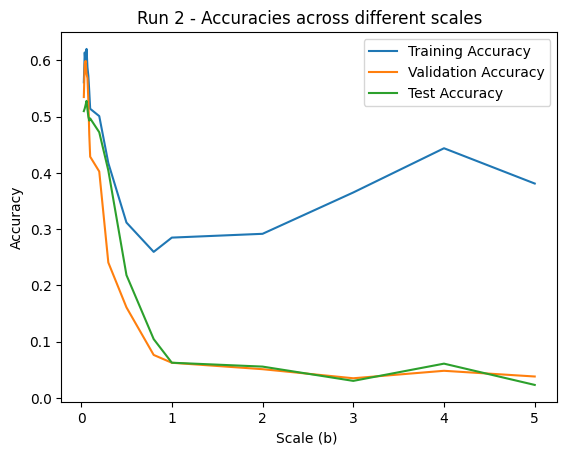

In [19]:


file_path = "Plotting metrics for all bs_withmore.pickle"

with open(file_path, 'rb') as file:
    # Load the dictionary from the pickle file
    plot_metrics = pickle.load(file)


plt.plot(plot_metrics["b"], plot_metrics["last train acc"], label='Training Accuracy')
plt.plot(plot_metrics["b"], plot_metrics["last validation acc"], label='Validation Accuracy')
plt.plot(plot_metrics["b"], plot_metrics["test acc"], label='Test Accuracy')


plt.xlabel('Scale (b) ')
plt.ylabel('Accuracy')
plt.title('Run 2 - Accuracies across different scales')
plt.legend()

# Display the plot

plt.savefig("run2 - accuracies across the scale.png")
plt.show()

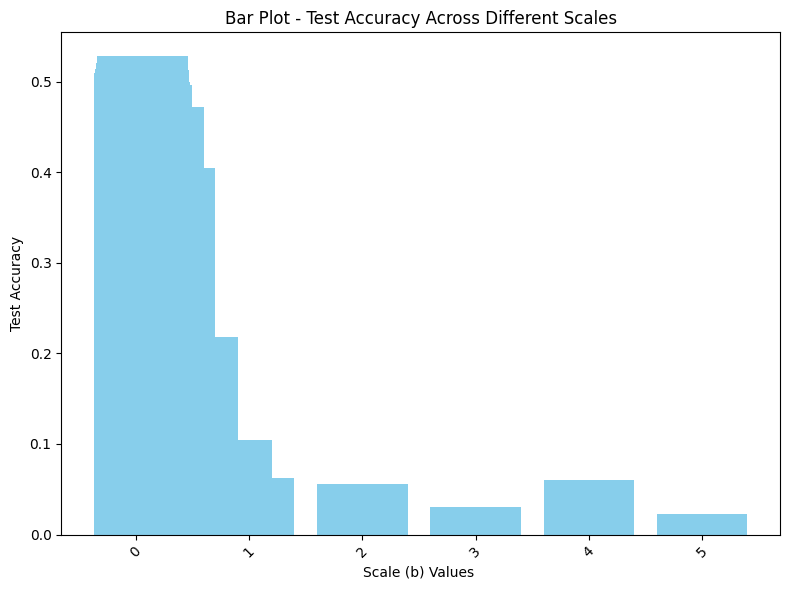

In [22]:
plt.figure(figsize=(8, 6))

plt.bar(plot_metrics["b"], plot_metrics["test acc"], color='skyblue')
plt.xlabel('Scale (b) Values ')
plt.ylabel('Test Accuracy')
plt.title('Bar Plot - Test Accuracy Across Different Scales')

plt.xticks(rotation=45)  # Rotating x-axis labels for better readability

plt.tight_layout()

plt.savefig("run2 - bar plot Test accuracy the scale.png")
plt.show()

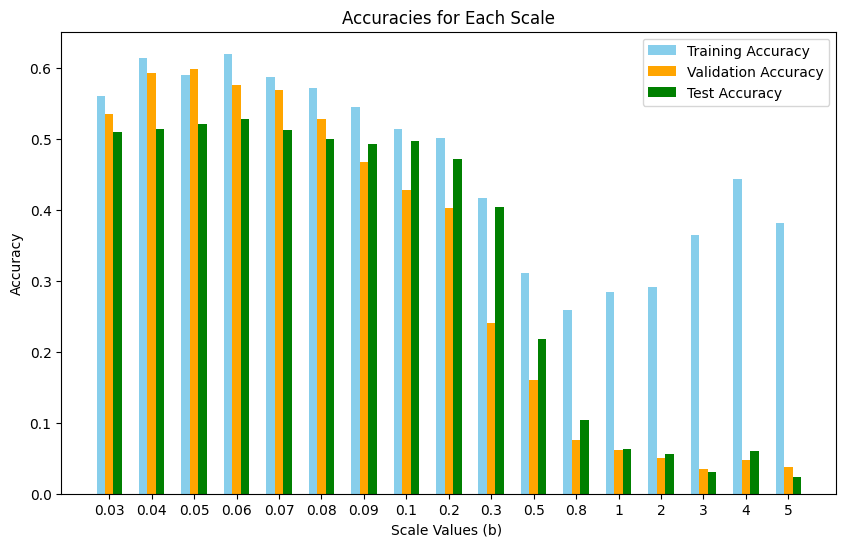

In [21]:
bar_width = 0.2  # Width of each bar
plt.close()
x = np.arange(len(plot_metrics["b"]))

# Plotting grouped bar plots
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
plt.bar(x, plot_metrics["last train acc"], width=bar_width, color='skyblue', label='Training Accuracy')
plt.bar(x + bar_width, plot_metrics["last validation acc"], width=bar_width, color='orange', label='Validation Accuracy')
plt.bar(x + 2 * bar_width, plot_metrics["test acc"], width=bar_width, color='green', label='Test Accuracy')

plt.xlabel('Scale Values (b) ')
plt.ylabel('Accuracy')
plt.title('Accuracies for Each Scale')
plt.xticks(x + bar_width, plot_metrics["b"])  # Set x-axis labels to category names

plt.legend()
#plt.tight_layout()

plt.savefig('run2_bar_plot_accuracies_along_the_scale.png', bbox_inches='tight')
plt.show()